In [77]:
import copy
import functools
import glob
import pickle
import scipy
import sklearn
import warnings

warnings.filterwarnings('ignore')

import itertools
import graphviz as gr
import numpy as np
import os
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import seaborn as sns


from matplotlib.ticker import MaxNLocator
from matplotlib import pyplot as plt
from matplotlib import style

from pprint import pprint
from scipy import stats, special
from sklearn import datasets, mixture
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

from urllib.request import urlopen
import json
with urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json') as response:
    counties = json.load(response)

import plotly.express as px
import plotly.figure_factory as ff

%matplotlib inline

style.use("fivethirtyeight")
pd.set_option("display.max_columns", 6)

np.random.seed(0)
pd.set_option('display.max_columns', None)

import dask
import dask.dataframe as dd
from dask.distributed import Client


### Load Filtered and Unfiltered CDPHE and TLGRF

In [2]:
DATA_FOLDER = "../data"
COLORADO_DATA_FOLDER = os.path.join(DATA_FOLDER,"Colorado_Data")
COLORADO_DF_PATH = os.path.join(COLORADO_DATA_FOLDER,"Colorado_Outbreak_Data_2021-09-01.csv")
MASTER_FIPS_PATH = os.path.join(COLORADO_DATA_FOLDER,"county_fips_master.csv")

In [3]:
CDPHE_w_TLGRF_merged = pd.read_csv("../data/CDPHE_TLGRF_historical_unfiltered.csv")
filtered_CDPHE_w_TLGRF_merged = pd.read_csv("../data/CDPHE_TLGRF_historical_filtered.csv")

CDPHE_w_TLGRF_merged["date"] = pd.to_datetime(CDPHE_w_TLGRF_merged["date"])
filtered_CDPHE_w_TLGRF_merged["date"] = pd.to_datetime(filtered_CDPHE_w_TLGRF_merged["date"])

In [4]:
0.026873*7+3.030824

3.218935

### Plot Decision Points

In [5]:
### Number of Decision points in old study?
old_capacities = pd.DataFrame(filtered_CDPHE_w_TLGRF_merged[filtered_CDPHE_w_TLGRF_merged["date"] <= "2021-09-30"].groupby("date")["capacity"].max())
old_capacities = old_capacities[old_capacities["capacity"] > 0]
#old_capacities = old_capacities.rename(columns={"changepoint":"capacity"})
print(old_capacities.sum())
old_capacities

capacity    99.0
dtype: float64


,capacity
date,
2020-03-23,1.0
2020-03-25,1.0
2020-03-30,1.0
2020-04-09,1.0
2020-04-21,1.0
...,...
2021-09-10,1.0
2021-09-13,1.0
2021-09-14,1.0


In [70]:
### Number of Decision points in new study?
updated_capacities = pd.DataFrame(filtered_CDPHE_w_TLGRF_merged.groupby("date")["capacity"].max())
updated_capacities = updated_capacities[updated_capacities["capacity"] > 0]
#updated_capacities = updated_capacities.rename(columns={"changepoint":"capacity"})
print(updated_capacities.sum())
date_range = pd.date_range(start=updated_capacities.index[0], end=updated_capacities.index[-1], freq='D')
updated_capacities = updated_capacities.reindex(date_range, fill_value=0)
updated_capacities

capacity    182.0
dtype: float64


,capacity
2020-03-23,1.0
2020-03-24,0.0
2020-03-25,1.0
2020-03-26,0.0
2020-03-27,0.0
...,...
2022-12-19,0.0
2022-12-20,0.0
2022-12-21,0.0
2022-12-22,0.0


In [71]:
updated_capacities.index

DatetimeIndex(['2020-03-23', '2020-03-24', '2020-03-25', '2020-03-26',
               '2020-03-27', '2020-03-28', '2020-03-29', '2020-03-30',
               '2020-03-31', '2020-04-01',
               ...
               '2022-12-14', '2022-12-15', '2022-12-16', '2022-12-17',
               '2022-12-18', '2022-12-19', '2022-12-20', '2022-12-21',
               '2022-12-22', '2022-12-23'],
              dtype='datetime64[ns]', length=1006, freq='D')

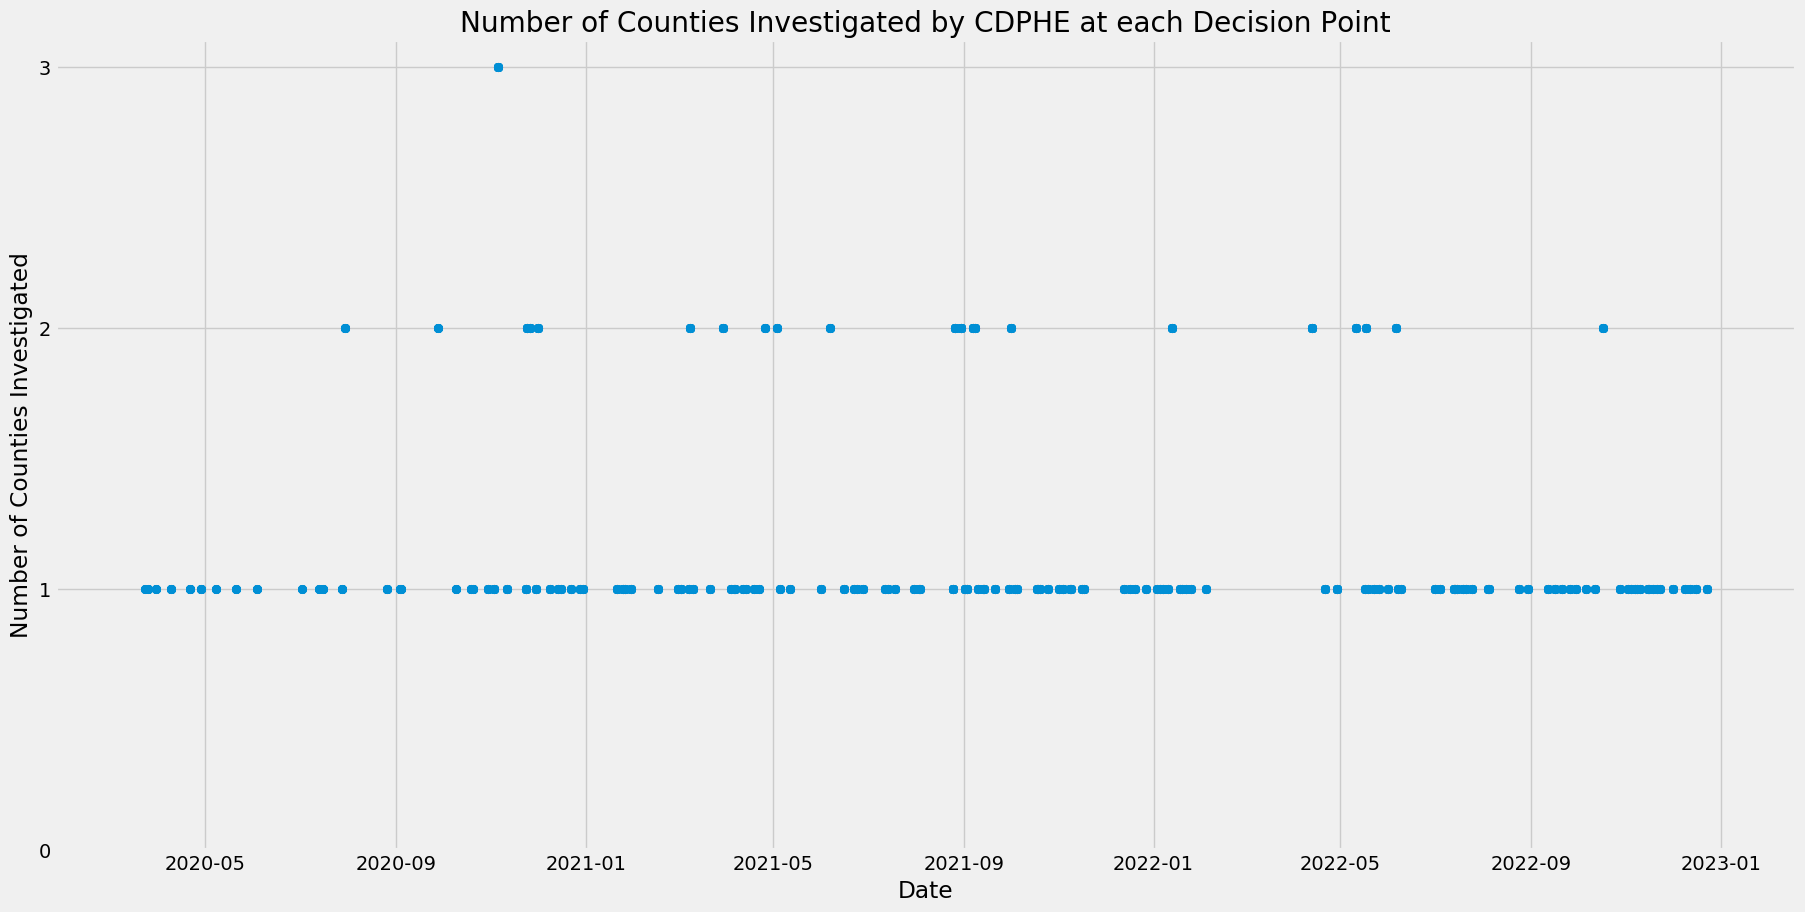

In [81]:
plt.figure(figsize=(20,10))
mask = (filtered_CDPHE_w_TLGRF_merged["capacity"] > 0) & (filtered_CDPHE_w_TLGRF_merged["date"] <= ("2022-12-31") )
plt.scatter(filtered_CDPHE_w_TLGRF_merged[mask]["date"], filtered_CDPHE_w_TLGRF_merged[mask]["capacity"])
plt.ylim(bottom=0)
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

plt.ylabel("Number of Counties Investigated")
plt.xlabel("Date")
plt.title("Number of Counties Investigated by CDPHE at each Decision Point")
plt.savefig("../figures/Capacity_CDPHE.png")

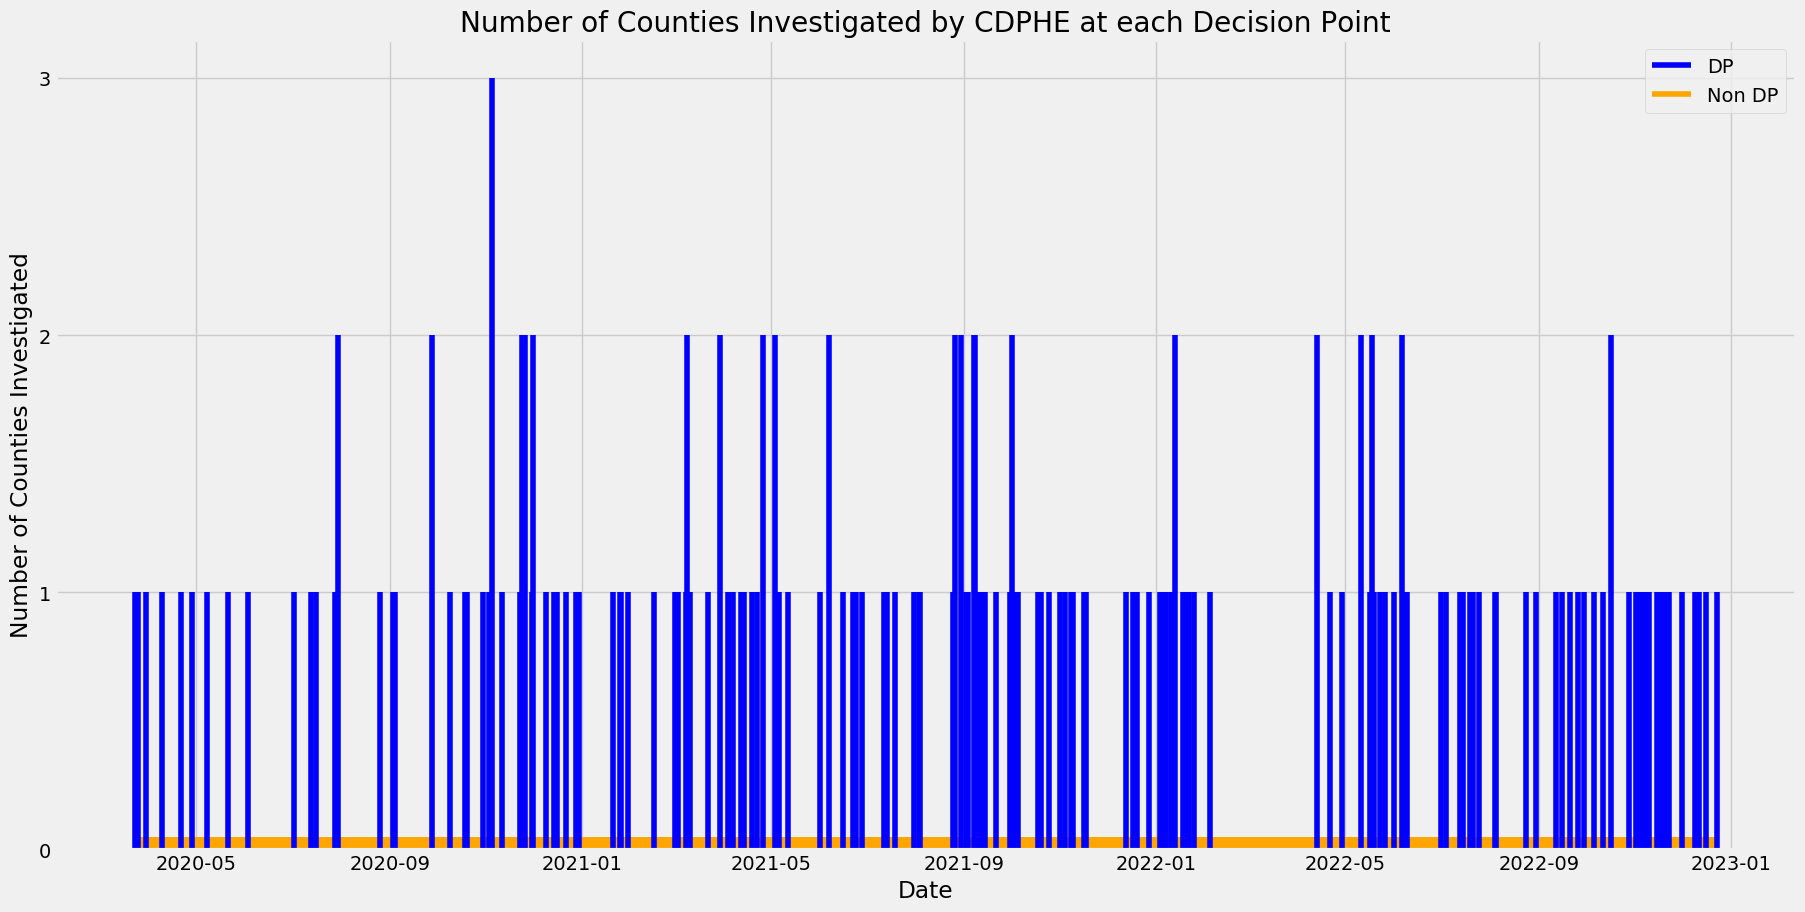

In [93]:
# Create a mask for points with 0 and points > 0
mask_zero = updated_capacities['capacity'] == 0
mask_non_zero = updated_capacities['capacity'] > 0

# Your plotting code
plt.figure(figsize=(20, 10))

# Plot vertical lines for points with 0 in blue
plt.vlines(updated_capacities[mask_zero].index, ymin=0, ymax=updated_capacities[mask_zero]['capacity'] + 0.05, colors='orange', label='Non DP')


# Plot vertical lines for points > 0 in orange
plt.vlines(updated_capacities[mask_non_zero].index, ymin=0, ymax=updated_capacities[mask_non_zero]['capacity'], colors='blue', label='DP')


# Set y-axis ticks to display only integers
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

# Set y-axis limits to start at 0
plt.ylim(bottom=0)

# Other plotting settings...
plt.xlabel('Date')
plt.ylabel('Number of Counties Investigated')
plt.title('Number of Counties Investigated by CDPHE at each Decision Point')

# Add legend
# Get legend handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Reverse the order
handles = handles[::-1]
labels = labels[::-1]

# Add legend with reversed order
plt.legend(handles, labels)

# Save the plot
plt.savefig('../figures/Capacity_CDPHE_with_zero.png')

# Show the plot
plt.show()


In [8]:
### CDPHE Capacity per DP
CDPHE_capacity_counts = pd.DataFrame(updated_capacities.value_counts())
CDPHE_capacity_counts = CDPHE_capacity_counts.sort_index()
CDPHE_capacity_counts

,0
capacity,
1.0,137
2.0,21
3.0,1


### Plot Threshold Against Capacity

thresh_cap = pd.merge(colorado_TLGRF, capacity_df, how="right", left_on="date.x", right_on="datetime")
thresh_cap["rank_unfiltered"] = thresh_cap.groupby("date.x")["predictor"].rank(method="dense", ascending=False)


overall_thresh = pd.merge(thresh_cap, changepoint_panel_df, how="left", left_on=["date.x", "fips"], right_on=["datetime","fips"])
overall_thresh = pd.merge(overall_thresh, outbreak_matrix_df, how="left", left_on=["date.x", "fips"], right_on=["datetime","fips"])

overall_thresh = overall_thresh[(overall_thresh["outbreak"] == 0) | (overall_thresh["changepoint"] == 1)]
overall_thresh = overall_thresh.drop(["datetime", "datetime_x", "datetime_y"], axis=1)
overall_thresh["rank_filtered"] =   overall_thresh.groupby("date.x")["predictor"].rank(method="dense", ascending=False)
overall_thresh["delta_ranked"] = overall_thresh.groupby("date.x")["delta cases"].rank(method="dense", ascending=False)
overall_thresh

In [9]:
threshold = 5
filtered_CDPHE_w_TLGRF_merged["threshold_decision"] = filtered_CDPHE_w_TLGRF_merged["TLGRF_predictor"] >= threshold
filtered_CDPHE_w_TLGRF_merged["threshold_capacity"] = filtered_CDPHE_w_TLGRF_merged.groupby("date")["threshold_decision"].transform("sum")
filtered_CDPHE_w_TLGRF_merged

,datetime_x,fips,changepoint,outbreak,capacity,county_x,state_x,date.x,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,predicted.grf.past,predicted.grf.past.0,predicted.grf.past.last,log_rolled_cases.x.y,block.mse,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x,date,county_y,state_y,cases,deaths,datetime_y,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,log_rolled_cases,shifted_log_rolled_cases,delta cases,delta_ranked,TLGRF_predictor,TLGRF_predictor_rank,TLGRF_decision,P,N,CDPHE_TP,TLGRF_TP,CDPHE_FP,TLGRF_FP,CDPHE_FN,TLGRF_FN,threshold_decision,threshold_capacity
0,2020-10-19,8003,0.0,0,1.0,Alamosa,Colorado,2020-10-19,20.0,272.0,3.509411,225.732268,0.084999,4.527718,4.104722,4.104406,8.154744,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-19,Alamosa,Colorado,43.0,9.0,2020-10-19,33.428571,37.568442,-105.788041,722.576715,16444.0,6936.0,6153.0,3635.0,708.0,21328.0,1287.0,2113.0,3932.0,2948.0,387.0,8504.0,640.0,451.0,1113.0,196.0,506.0,1089.0,23.7,4.1,9.3,3.3,21328.0,1792.0,13.5,2.5,12.8,0.2,23.9,0.3,18.4,2.0,6.3,2.2,51.7,0.3,4.2,1.7,6.5,2.1,16.0,2.4,3.2,1.7,8.2,2.9,6.6,1.5,0.8911,0.9121,0.8417,0.5772,3.2221,0.8669,0.0952,0.7122,0.7358,0.2069,1.7501,0.2958,0.8863,0.8968,1.7831,0.9331,0.7771,0.6778,0.7953,0.8026,0.8650,3.9178,0.9943,10.6731,0.9452,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2237.0,14.0,3.0,16662.0,3.509411,3.923387,17.142857,4.0,2.841404,2.0,0,False,True,False,False,False,False,False,False,False,0
1,2020-10-20,8003,1.0,1,1.0,Alamosa,Colorado,2020-10-20,23.0,273.0,3.599267,223.360822,0.079745,4.516665,4.147367,4.157479,8.692097,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-10-20,Alamosa,Colorado,46.0,9.0,2020-10-20,36.571429,37.568442,-105.788041,722.576715,16444.0,6936.0,6153.0,3635.0,708.0,21328.0,1287.0,2113.0,3932.0,2948.0,387.0,8504.0,640.0,451.0,1113.0,196.0,506.0,1089.0,23.7,4.1,9.3,3.3,21328.0,1792.0,13.5,2.5,12.8,0.2,23.9,0.3,18.4,2.0,6.3,2.2,51.7,0.3,4.2,1.7,6.5,2.1,16.0,2.4,3.2,1.7,8.2,2.9,6.6,1.5,0.8911,0.9121,0.8417,0.5772,3.2221,0.8669,0.0952,0.7122,0.7358,0.2069,1.7501,0.2958,0.8863,0.8968,1.7831,0.9331,0.7771,0.6778,0.7953,0.8026,0.8650,3.9178,0.9943,10.6731,0.9452,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2237.0,14.0,3.0,16662.0,3.599267,3.948493,15.285714,3.0,2.916371,1.0,1,False,True,False,False,True,True,False,False,False,0
2,2021-04-04,8003,0.0,0,1.0,Alamosa,Colorado,2021-04-04,9.0,439.0,3.443162,547.776890,-0.030302,3.084045,3.232209,3.231047,-22.874621,2.940266,3.301478,3.285081,3.767823,0.252904,-12.000000,0.020074,0.024989,0.502895,0.141683,0.158080,0.146056,0.041149,0.045911,NaN,2021-04-04,Alamosa,Colorado,26.0,29.0,2021-04-04,31.285714,37.568442,-105.788041,722.576715,16444.0,6936.0,6153.0,3635.0,708.0,21328.0,1287.0,2113.0,3932.0,2948.0,387.0,8504.0,640.0,451.0,1113.0,196.0,506.0,1089.0,23.7,4.1,9.3,3.3,21328.0,1792.0,1

In [10]:
def binary_classification_performance_threshold_DP(df, date_col="date", outcome_col="delta_ranked", predictor_col="TLGRF_predictor", threshold=5):
    # Redefine Capacity based off how many picked
    
    # Compute TP, TN, FP, FN
    df["threshold_decision"] = df[predictor_col] >= threshold
    df["threshold_capacity"] = df.groupby(date_col)["threshold_decision"].transform("sum")

    
    #print(selected_df)
    
    Results_Thresh = pd.DataFrame()
    #Total
    Total_Decision_Set = df.groupby(date_col)[outcome_col].size()
    Results_Thresh["Total"] = Total_Decision_Set    
    #print(Results_Thresh.shape)
    
    #P Capacity is now how many were chosen by the threshold policy
    P = df.groupby(date_col)["threshold_capacity"].max()
    Results_Thresh["P"] = P
    
    #TP
    TP = df.groupby(date_col).apply(lambda x: ( (x[outcome_col] <= x["threshold_capacity"]) & (x["threshold_decision"] == 1)  ).sum())
    Results_Thresh["TP"] = TP
    #FP = FN
    FP = df.groupby(date_col).apply(lambda x: ((x[outcome_col] > x["threshold_capacity"]) & (x["threshold_decision"] == 1)).sum())
    Results_Thresh["FP"] = FP
    Results_Thresh["FN"] = Results_Thresh["FP"]
    #N
    Results_Thresh["N"] = Results_Thresh["Total"] - Results_Thresh["P"]
    Results_Thresh["TN"] = Results_Thresh["N"] - Results_Thresh["FN"]
    #TN
    Results_Thresh = Results_Thresh[["Total", "P", "N", "TP", "FP", "FN", "TN"]]
    
    TP = Results_Thresh.sum()["TP"]
    FP = Results_Thresh.sum()["FP"]
    FN = Results_Thresh.sum()["FN"]
    TN = Results_Thresh.sum()["TN"]


    PPV = Results_Thresh.sum()["TP"]/(Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FP"])
    FPV = Results_Thresh.sum()["FP"]/(Results_Thresh.sum()["TN"] + Results_Thresh.sum()["FP"])
    TPR = Results_Thresh.sum()["TP"]/(Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FN"])
    TNR = Results_Thresh.sum()["TN"]/(Results_Thresh.sum()["TN"] + Results_Thresh.sum()["FP"])

    Precision = Results_Thresh.sum()["TP"] / (Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FP"])
    Recall = Results_Thresh.sum()["TP"] / (Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FN"])
    F1 = 2 * Precision * Recall / (Precision + Recall)

    # create a pandas dataframe from the confusion matrix values
    confusion_table = pd.DataFrame({'actual_positive': [1, 1, 0, 0], 'predicted_positive': [0, 1, 0, 1], 'count': [FN, TP, TN, FP]})

    # create a pivot table to represent the confusion matrix
    confusion_matrix = pd.pivot_table(confusion_table, values='count', index=['actual_positive'], columns=['predicted_positive'])

    # set the column and index names of the pivot table
    confusion_matrix.columns.name = 'Predicted Label'
    confusion_matrix.index.name = 'Actual Label'
    #confusion_matrix = confusion_matrix.T


    print("PPV={}, FPV={}\nTPR={}, TNR={}\nF1={}".format(PPV, FPV, TPR, TNR, F1))
    print(Results_Thresh.sum())
    confusion_matrix
    
    return Results_Thresh, (PPV, FPV, TPR, TNR, F1), confusion_matrix

### Threshold for DPs Only

In [11]:
binary_classification_performance_threshold_DP(filtered_CDPHE_w_TLGRF_merged, date_col="date", outcome_col="delta_ranked", predictor_col="TLGRF_predictor", threshold=5)

PPV=0.7745098039215687, FPV=0.022083533365338453
TPR=0.7745098039215687, TNR=0.9779164666346616
F1=0.7745098039215687
Total    2287
P         204
N        2083
TP        158
FP         46
FN         46
TN       2037
dtype: int64


(            Total  P   N  TP  FP  FN  TN
 date                                    
 2020-03-23      3  3   0   3   0   0   0
 2020-03-25      4  4   0   4   0   0   0
 2020-03-30      4  3   1   3   0   0   1
 2020-04-09      7  1   6   1   0   0   6
 2020-04-21      6  0   6   0   0   0   6
 ...           ... ..  ..  ..  ..  ..  ..
 2022-12-01     16  0  16   0   0   0  16
 2022-12-09     16  0  16   0   0   0  16
 2022-12-12     15  0  15   0   0   0  15
 2022-12-16     16  0  16   0   0   0  16
 2022-12-23     14  0  14   0   0   0  14
 
 [159 rows x 7 columns],
 (0.7745098039215687,
  0.022083533365338453,
  0.7745098039215687,
  0.9779164666346616,
  0.7745098039215687),
 Predicted Label     0    1
 Actual Label              
 0                2037   46
 1                  46  158)

In [13]:
### Investigations per Decision Point by Threshold=5 (DP Only)
#Threshold_DP_counts = pd.DataFrame(plotted_df["threshold_capacity"].value_counts())
#print(Threshold_DP_counts.sum())
#Threshold_DP_counts = Threshold_DP_counts.sort_index()
#Threshold_DP_counts

### Threshold Policy All Datetime

In [57]:
def threshold_capacities_all_time(CDPHE_w_TLGRF_merged, threshold=5):
    all_datetime_df = CDPHE_w_TLGRF_merged.copy()
    all_datetime_df = all_datetime_df[(all_datetime_df["outbreak"] == 0) | (all_datetime_df["changepoint"] == 1)]
    all_datetime_df["TLGRF_predictor"] = all_datetime_df["tau.hat"]*np.exp(all_datetime_df["log_rolled_cases"])

    all_datetime_df["threshold_decision={}".format(threshold)] = (all_datetime_df["TLGRF_predictor"] >= threshold)
    all_datetime_df["threshold_capacity={}".format(threshold)] = all_datetime_df.groupby("date")["threshold_decision={}".format(threshold)].transform("sum")
    all_datetime_df_capacity_counts = pd.DataFrame(all_datetime_df.groupby("date")["threshold_capacity={}".format(threshold)].max())
    #all_datetime_df_capacity_counts = all_datetime_df_capacity_counts.sort_values(by=all_datetime_df_capacity_counts.index)
    all_datetime_df_capacity_counts = pd.DataFrame(all_datetime_df_capacity_counts.value_counts()).sort_index()
    all_datetime_df_capacity_counts = all_datetime_df_capacity_counts.reset_index()
    
    all_datetime_df_capacity_counts = all_datetime_df_capacity_counts.rename(columns={"threshold_capacity={}".format(threshold) : "# Counties Investigated", 0: "threshold_capacity={}".format(threshold)})
    #all_datetime_df_capacity_counts = all_datetime_df_capacity_counts.fillna(0)
    return (all_datetime_df_capacity_counts)

In [58]:
thresh5 = threshold_capacities_all_time(CDPHE_w_TLGRF_merged, threshold=5)

In [66]:
#threshold_values = list(range(1, 11)) + [20, 30, 40, 50]
threshold_values = [5, 10, 30]

outputs = [threshold_capacities_all_time(CDPHE_w_TLGRF_merged, threshold) for threshold in threshold_values]
merged_data = pd.DataFrame(index=pd.Series(range(max(max(df.index) for df in outputs))))

for i, output in enumerate(outputs):
    output.columns = ["# Counties Investigated"] + [f"threshold_capacity={threshold_values[i]}"]
    merged_data = pd.merge(merged_data, output, how='outer', left_index=True, right_index=True, suffixes=('', '_drop'))

    # Dropping the right column with the same name as the left
    drop_cols = [col for col in merged_data.columns if col.endswith('_drop')]
    merged_data.drop(drop_cols, axis=1, inplace=True)
filled_merged_data = merged_data.fillna(0)
filled_merged_data.loc[filled_merged_data['# Counties Investigated'] >= 4, filled_merged_data.columns[1:]] = filled_merged_data.loc[filled_merged_data['# Counties Investigated'] >= 4, merged_data.columns[1:]].apply(lambda x: x.mask(x >= 4, x.sum(), axis=0))

truncated_merged_data = filled_merged_data[filled_merged_data.index <= 4]
truncated_merged_data = truncated_merged_data[truncated_merged_data.index > 0]

truncated_merged_data

,# Counties Investigated,threshold_capacity=5,threshold_capacity=10,threshold_capacity=30
1,1,300,342.0,331.0
2,2,167,103.0,38.0
3,3,75,43.0,6.0
4,4,86,33.0,0.0


In [61]:
merged_data.loc[merged_data['# Counties Investigated'] >= 4, merged_data.columns[1:]] = merged_data.loc[merged_data['# Counties Investigated'] >= 4, merged_data.columns[1:]].apply(lambda x: x.mask(x >= 4, x.sum(), axis=0))


In [62]:
merged_data

,# Counties Investigated,threshold_capacity=5,threshold_capacity=10,threshold_capacity=30
0,0,384,491.0,637.0
1,1,300,342.0,331.0
2,2,167,103.0,38.0
3,3,75,43.0,6.0
4,4,86,33.0,0.0
5,5,86,33.0,0.0
6,6,86,33.0,0.0
7,7,86,2.0,0.0
8,8,86,3.0,0.0
9,9,86,33.0,0.0


In [ ]:
break

In [14]:
all_datetime_df = CDPHE_w_TLGRF_merged.copy()
# Filter keep only (outbreak == 0) | (changepoint == 1)
all_datetime_df = all_datetime_df[(all_datetime_df["outbreak"] == 0) | (all_datetime_df["changepoint"] == 1)]
# Compute predictor: TLGRF_predictor
all_datetime_df["TLGRF_predictor"] = all_datetime_df["tau.hat"]*np.exp(all_datetime_df["log_rolled_cases"])
all_datetime_df["TLGRF_predictor_rank"]  = all_datetime_df.groupby("date")["TLGRF_predictor"].rank(method="dense", ascending=False)
# Compute outcome: delta and delta_ranked
all_datetime_df["delta"] = np.exp(all_datetime_df["shifted_log_rolled_cases"]) - np.exp(all_datetime_df["log_rolled_cases"])
all_datetime_df["delta_ranked"]  = all_datetime_df.groupby("date")["delta"].rank(method="dense", ascending=False)
# Compute threshold policy
all_datetime_df["threshold_decision"] = (all_datetime_df["TLGRF_predictor"] >= threshold)
all_datetime_df["threshold_capacity"] = all_datetime_df.groupby("date")["threshold_decision"].transform("sum")
all_datetime_df

,datetime_x,fips,changepoint,outbreak,capacity,county_x,state_x,date.x,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,predicted.grf.past,predicted.grf.past.0,predicted.grf.past.last,log_rolled_cases.x.y,block.mse,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x,date,county_y,state_y,cases,deaths,datetime_y,rolled_cases,LAT,LON,AREA_SQMI,E_TOTPOP,E_HU,E_HH,E_POV,E_UNEMP,E_PCI,E_NOHSDP,E_AGE65,E_AGE17,E_DISABL,E_SNGPNT,E_MINRTY,E_LIMENG,E_MUNIT,E_MOBILE,E_CROWD,E_NOVEH,E_GROUPQ,EP_POV,MP_POV,EP_UNEMP,MP_UNEMP,EP_PCI,MP_PCI,EP_NOHSDP,MP_NOHSDP,EP_AGE65,MP_AGE65,EP_AGE17,MP_AGE17,EP_DISABL,MP_DISABL,EP_SNGPNT,MP_SNGPNT,EP_MINRTY,MP_MINRTY,EP_LIMENG,MP_LIMENG,EP_MUNIT,MP_MUNIT,EP_MOBILE,MP_MOBILE,EP_CROWD,MP_CROWD,EP_NOVEH,MP_NOVEH,EP_GROUPQ,MP_GROUPQ,EPL_POV,EPL_UNEMP,EPL_PCI,EPL_NOHSDP,SPL_THEME1,RPL_THEME1,EPL_AGE65,EPL_AGE17,EPL_DISABL,EPL_SNGPNT,SPL_THEME2,RPL_THEME2,EPL_MINRTY,EPL_LIMENG,SPL_THEME3,RPL_THEME3,EPL_MUNIT,EPL_MOBILE,EPL_CROWD,EPL_NOVEH,EPL_GROUPQ,SPL_THEME4,RPL_THEME4,SPL_THEMES,RPL_THEMES,F_POV,F_UNEMP,F_PCI,F_NOHSDP,F_THEME1,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,log_rolled_cases,shifted_log_rolled_cases,TLGRF_predictor,TLGRF_predictor_rank,delta,delta_ranked,threshold_decision,threshold_capacity
1061,2020-08-07,8003,0.0,0,0.0,Alamosa,Colorado,2020-08-07,2.0,199.0,2.995732,576.522337,-0.007917,2.933559,2.932393,2.940311,-87.547760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-07,Alamosa,Colorado,20.0,9.0,2020-08-07,20.000000,37.568442,-105.788041,722.576715,16444.0,6936.0,6153.0,3635.0,708.0,21328.0,1287.0,2113.0,3932.0,2948.0,387.0,8504.0,640.0,451.0,1113.0,196.0,506.0,1089.0,23.7,4.1,9.3,3.3,21328.0,1792.0,13.5,2.5,12.8,0.2,23.9,0.3,18.4,2.0,6.3,2.2,51.7,0.3,4.2,1.7,6.5,2.1,16.0,2.4,3.2,1.7,8.2,2.9,6.6,1.5,0.8911,0.9121,0.8417,0.5772,3.2221,0.8669,0.0952,0.7122,0.7358,0.2069,1.7501,0.2958,0.8863,0.8968,1.7831,0.9331,0.7771,0.6778,0.7953,0.8026,0.8650,3.9178,0.9943,10.6731,0.9452,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2237.0,14.0,3.0,16662.0,2.995732,3.051302,-0.158347,5.0,1.142857,5.0,False,0
1062,2020-08-08,8003,0.0,0,0.0,Alamosa,Colorado,2020-08-08,3.0,200.0,2.995732,-163.987163,0.008496,3.151787,3.063698,3.055202,81.588220,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-08,Alamosa,Colorado,20.0,9.0,2020-08-08,20.000000,37.568442,-105.788041,722.576715,16444.0,6936.0,6153.0,3635.0,708.0,21328.0,1287.0,2113.0,3932.0,2948.0,387.0,8504.0,640.0,451.0,1113.0,196.0,506.0,1089.0,23.7,4.1,9.3,3.3,21328.0,1792.0,13.5,2.5,12.8,0.2,23.9,0.3,18.4,2.0,6.3,2.2,51.7,0.3,4.2,1.7,6.5,2.1,16.0,2.4,3.2,1.7,8.2,2.9,6.6,1.5,0.8911,0.9121,0.8417,0.5772,3.2221,0.8669,0.0952,0.7122,0.7358,0.2069,1.7501,0.2958,0.8863,0.8968,1.7831,0.9331,0.7771,0.6778,0.7953,0.8026,0.8650,3.9178,0.9943,10.6731,0.9452,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2237.0,14.0,3.0,16662.0,2.995732,3.009917,0.169914,4.0,0.285714,5.0,False,0
1063,2020-08-09,8003,0.0,0,0.0,Alamosa,Colorado,2020-08-09,6.0,201.0,3.016934,42.774272,0.019689,3.253208,3.153248,3.154761,35.203940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-09,Alamosa,Colorado,23.0,9.0,2020-08-09,20.428571,37.568442,-105.788041,722.576715,16444.0,6936.0,6153.0,3635.0,708.0,21328.0,1287.0,2113.0,3932.0,2948.0,387.0,8504.0,640.0,451.0,1113.0,196.0,506.0,1089.0,23.7,4.1,9.3,3.3,21328.0,1792.0,13.5,2.5,12.8,0.2,23.9,0.3,18.4,2.0,6.3,2.2,51.7,0.3,4.2,1.7,6.5,2.1,16.0,2.4,3.2,1.7,8.2,2.9,6.6,1.5,0.8911,0.9121,0.8417,0.5772,3.2221,0.8669,0.0952,0.7122,0.7358,0.2069,1.7501,0.2958,0.8863,0.8968,1.7831,0.9331,0.7771,0.6778,0.7953,0.8026

In [15]:
len(all_datetime_df["date"].unique())

1012

In [16]:
all_datetime_df["date"].max() - all_datetime_df["date"].min()

Timedelta('1011 days 00:00:00')

In [17]:
def binary_classification_performance_threshold_all_dates(df, date_col="date", outcome_col="delta_ranked", predictor_col="TLGRF_predictor", threshold=5):
    # Redefine Capacity based off how many picked
    
    # Compute TP, TN, FP, FN
    #print(selected_df)
    
    Results_Thresh = pd.DataFrame()
    #Total
    Total_Decision_Set = df.groupby(date_col)[outcome_col].size()
    Results_Thresh["Total"] = Total_Decision_Set    
    #print(Results_Thresh.shape)
    
    #P Capacity is now how many were chosen by the threshold policy
    P = df.groupby(date_col)["threshold_capacity"].max()
    Results_Thresh["P"] = P
    
    #TP
    TP = df.groupby(date_col).apply(lambda x: ( (x[outcome_col] <= x["threshold_capacity"]) & (x["threshold_decision"] == 1)  ).sum())
    Results_Thresh["TP"] = TP
    #FP = FN
    FP = df.groupby(date_col).apply(lambda x: ((x[outcome_col] > x["threshold_capacity"]) & (x["threshold_decision"] == 1)).sum())
    Results_Thresh["FP"] = FP
    Results_Thresh["FN"] = Results_Thresh["FP"]
    #N
    Results_Thresh["N"] = Results_Thresh["Total"] - Results_Thresh["P"]
    Results_Thresh["TN"] = Results_Thresh["N"] - Results_Thresh["FN"]
    #TN
    Results_Thresh = Results_Thresh[["Total", "P", "N", "TP", "FP", "FN", "TN"]]
    
    TP = Results_Thresh.sum()["TP"]
    FP = Results_Thresh.sum()["FP"]
    FN = Results_Thresh.sum()["FN"]
    TN = Results_Thresh.sum()["TN"]


    PPV = Results_Thresh.sum()["TP"]/(Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FP"])
    FPV = Results_Thresh.sum()["FP"]/(Results_Thresh.sum()["TN"] + Results_Thresh.sum()["FP"])
    TPR = Results_Thresh.sum()["TP"]/(Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FN"])
    TNR = Results_Thresh.sum()["TN"]/(Results_Thresh.sum()["TN"] + Results_Thresh.sum()["FP"])

    Precision = Results_Thresh.sum()["TP"] / (Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FP"])
    Recall = Results_Thresh.sum()["TP"] / (Results_Thresh.sum()["TP"] + Results_Thresh.sum()["FN"])
    F1 = 2 * Precision * Recall / (Precision + Recall)

    # create a pandas dataframe from the confusion matrix values
    confusion_table = pd.DataFrame({'actual_positive': [1, 1, 0, 0], 'predicted_positive': [0, 1, 0, 1], 'count': [FN, TP, TN, FP]})

    # create a pivot table to represent the confusion matrix
    confusion_matrix = pd.pivot_table(confusion_table, values='count', index=['actual_positive'], columns=['predicted_positive'])

    # set the column and index names of the pivot table
    confusion_matrix.columns.name = 'Predicted Label'
    confusion_matrix.index.name = 'Actual Label'
    #confusion_matrix = confusion_matrix.T


    print("PPV={}, FPV={}\nTPR={}, TNR={}\nF1={}".format(PPV, FPV, TPR, TNR, F1))
    print(Results_Thresh.sum())
    confusion_matrix
    
    return Results_Thresh, (PPV, FPV, TPR, TNR, F1), confusion_matrix

In [18]:
binary_classification_performance_threshold_all_dates(all_datetime_df, date_col="date", outcome_col="delta_ranked", predictor_col="TLGRF_predictor", threshold=5)

PPV=0.7485754985754985, FPV=0.02795818153017583
TPR=0.7485754985754985, TNR=0.9720418184698242
F1=0.7485754985754985
Total    14030
P         1404
N        12626
TP        1051
FP         353
FN         353
TN       12273
dtype: int64


(            Total  P   N  TP  FP  FN  TN
 date                                    
 2020-03-18      2  2   0   2   0   0   0
 2020-03-19      2  2   0   2   0   0   0
 2020-03-20      2  2   0   2   0   0   0
 2020-03-21      3  3   0   3   0   0   0
 2020-03-22      3  3   0   3   0   0   0
 ...           ... ..  ..  ..  ..  ..  ..
 2022-12-20     15  0  15   0   0   0  15
 2022-12-21     15  0  15   0   0   0  15
 2022-12-22     15  0  15   0   0   0  15
 2022-12-23     15  0  15   0   0   0  15
 2022-12-24     14  0  14   0   0   0  14
 
 [1012 rows x 7 columns],
 (0.7485754985754985,
  0.02795818153017583,
  0.7485754985754985,
  0.9720418184698242,
  0.7485754985754985),
 Predicted Label      0     1
 Actual Label                
 0                12273   353
 1                  353  1051)

In [19]:
all_datetime_df_capacity_counts = pd.DataFrame(all_datetime_df.groupby("date")["threshold_capacity"].max())
#all_datetime_df_capacity_counts = all_datetime_df_capacity_counts.sort_values(by=all_datetime_df_capacity_counts.index)
all_datetime_df_capacity_counts = pd.DataFrame(all_datetime_df_capacity_counts.value_counts()).sort_index()
print(all_datetime_df_capacity_counts.sum())
all_datetime_df_capacity_counts

0    1012
dtype: int64


,0
threshold_capacity,
0,384
1,300
2,167
3,75
4,23
5,23
6,9
7,8
8,5


Text(0.5, 1.0, 'Number of Investigations at CDPHE vs Threshold (DP only) vs Threshold (all time w/ uninvestigated counties)')

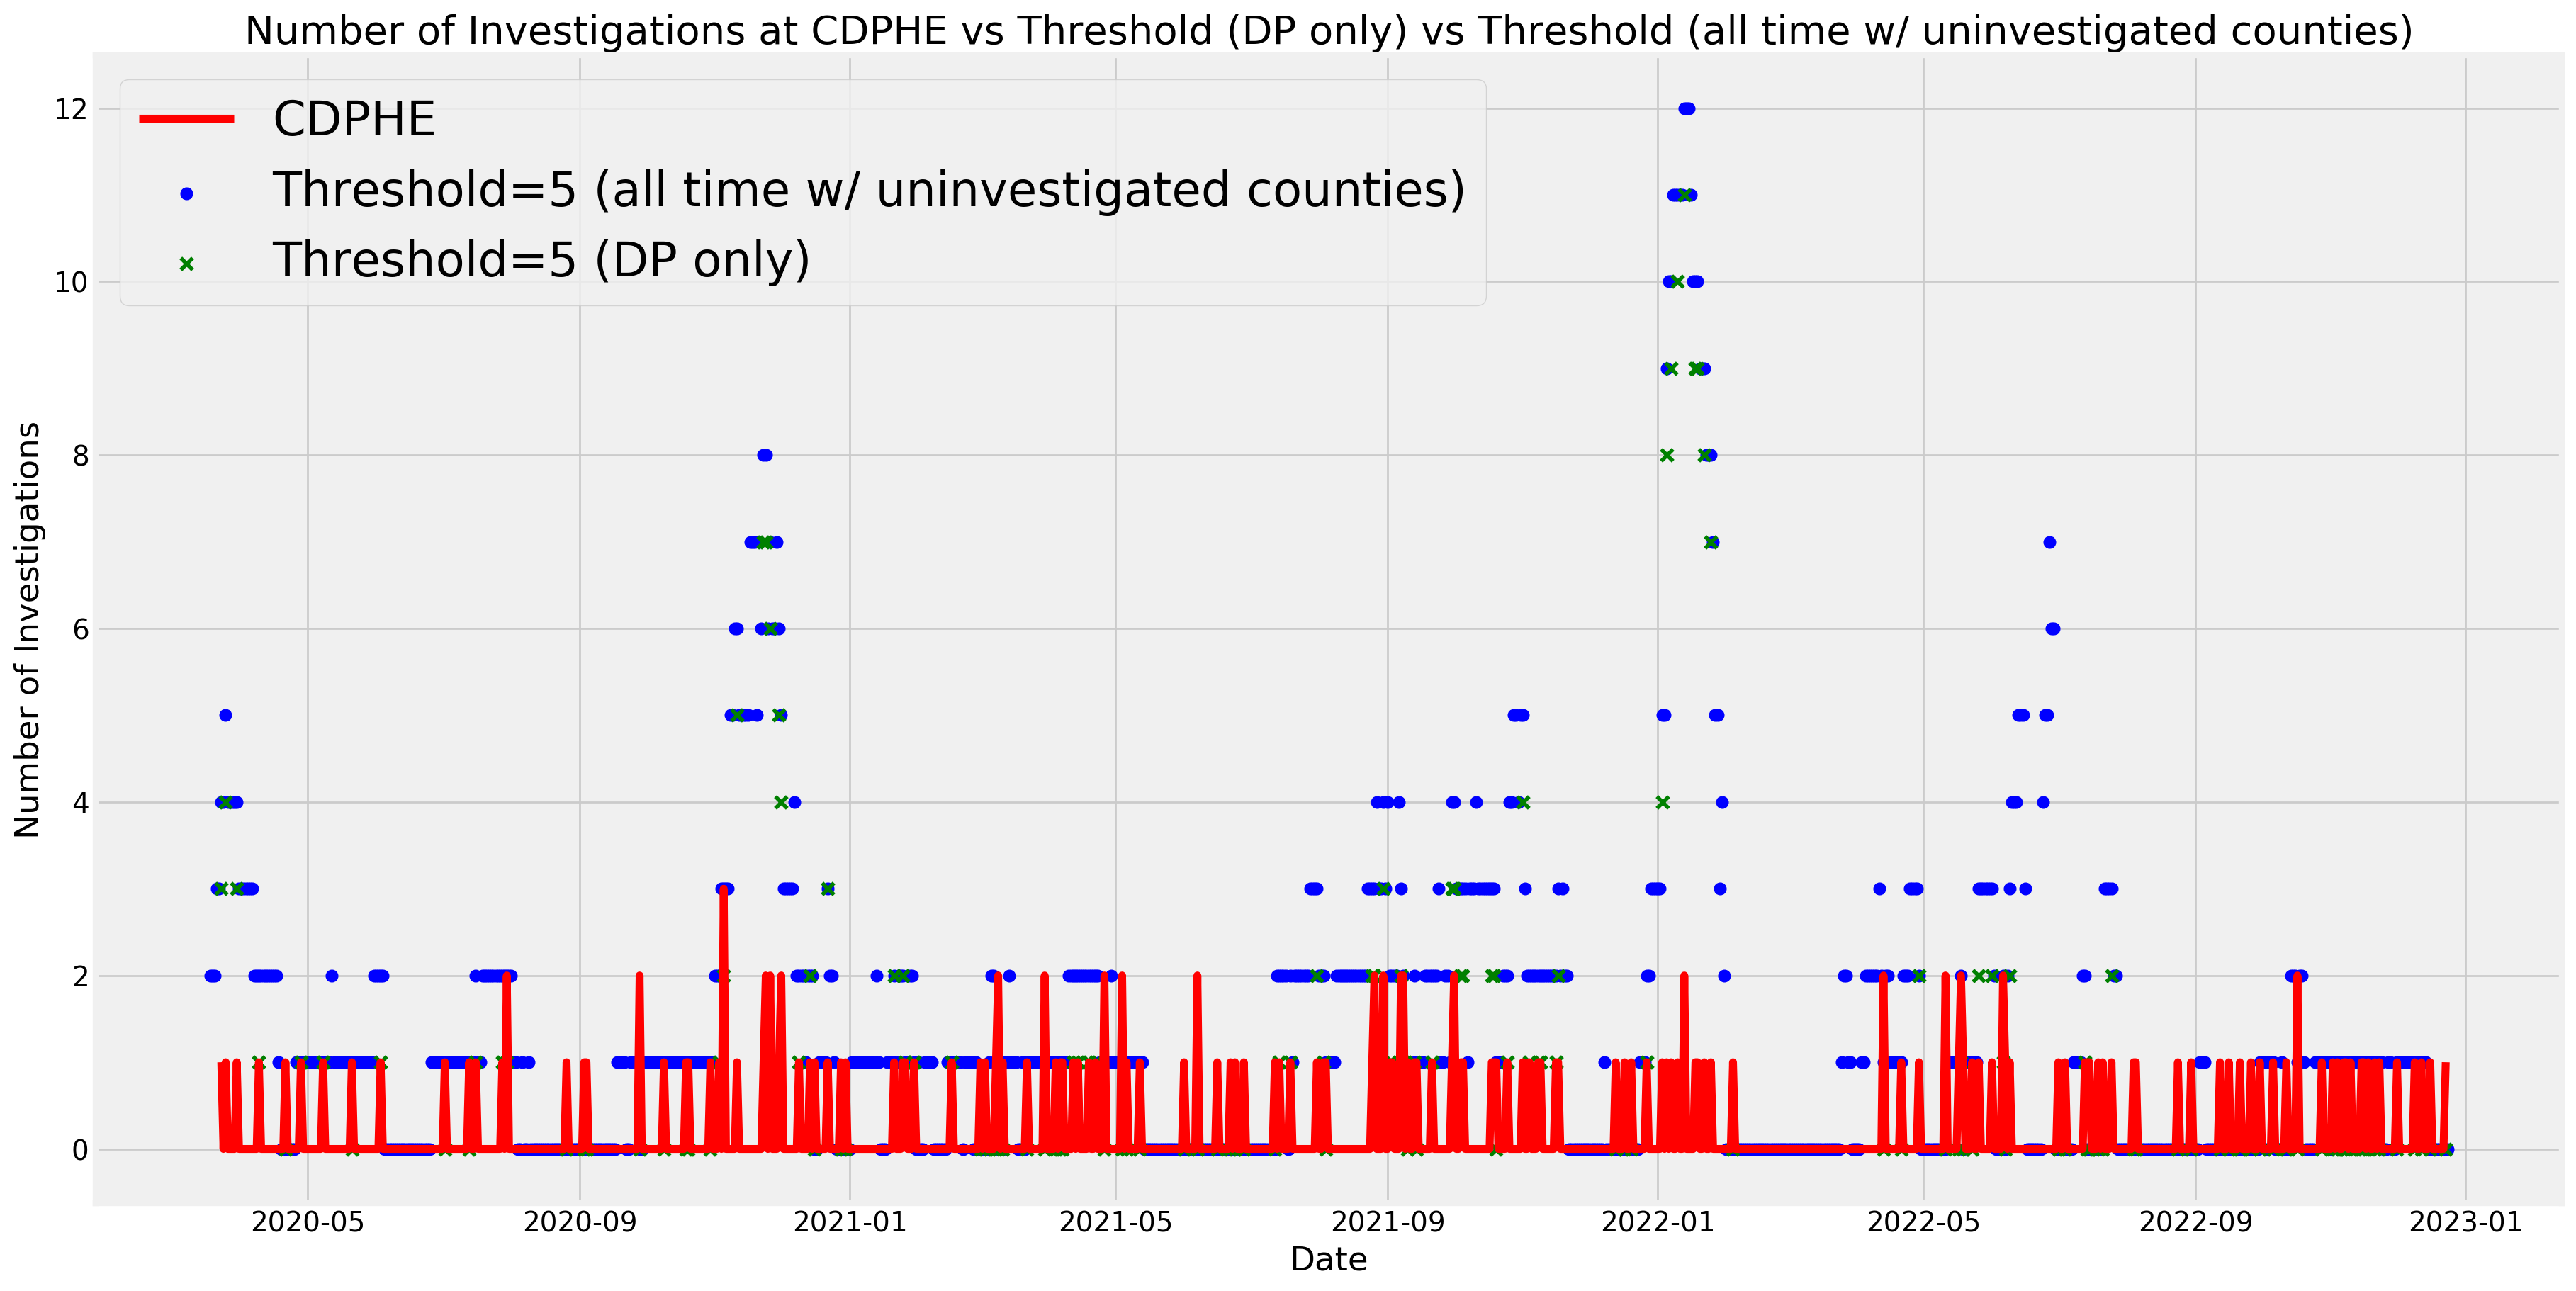

In [20]:
# Change to scatters
fig, ax = plt.subplots(1,1,figsize=(20,10), dpi= 200, facecolor='w', edgecolor='k')
selected_df = filtered_CDPHE_w_TLGRF_merged.copy()
selected_df["threshold_decision"] = (selected_df["TLGRF_predictor"] >= 5)
selected_df["threshold_capacity"] = selected_df.groupby("date")["threshold_decision"].transform("sum")

all_dates_plotted_df = pd.DataFrame(all_datetime_df.groupby("date")["capacity", "threshold_capacity"].max())


plotted_df = pd.DataFrame(selected_df.groupby("date")["capacity", "threshold_capacity"].max())
resampled_plotted_df = plotted_df.resample("D").asfreq().fillna(0)

plt.plot(resampled_plotted_df.index, resampled_plotted_df["capacity"], label="CDPHE", color='r')

plt.scatter(all_dates_plotted_df.index, all_dates_plotted_df["threshold_capacity"], label="Threshold={} (all time w/ uninvestigated counties)".format(threshold), color="b")

plt.scatter(plotted_df.index, plotted_df["threshold_capacity"], label="Threshold={} (DP only)".format(threshold), color="g", marker="x", linewidth=2)

plt.legend(fontsize='xx-large')
plt.xlabel("Date")
plt.ylabel("Number of Investigations")
plt.title("Number of Investigations at CDPHE vs Threshold (DP only) vs Threshold (all time w/ uninvestigated counties)")

In [21]:
plotted_df.resample("D").asfreq().fillna(0)

,capacity,threshold_capacity
date,,
2020-03-23,1.0,3.0
2020-03-24,0.0,0.0
2020-03-25,1.0,4.0
2020-03-26,0.0,0.0
2020-03-27,0.0,0.0
...,...,...
2022-12-19,0.0,0.0
2022-12-20,0.0,0.0
2022-12-21,0.0,0.0


NameError: name 'dp_df' is not defined

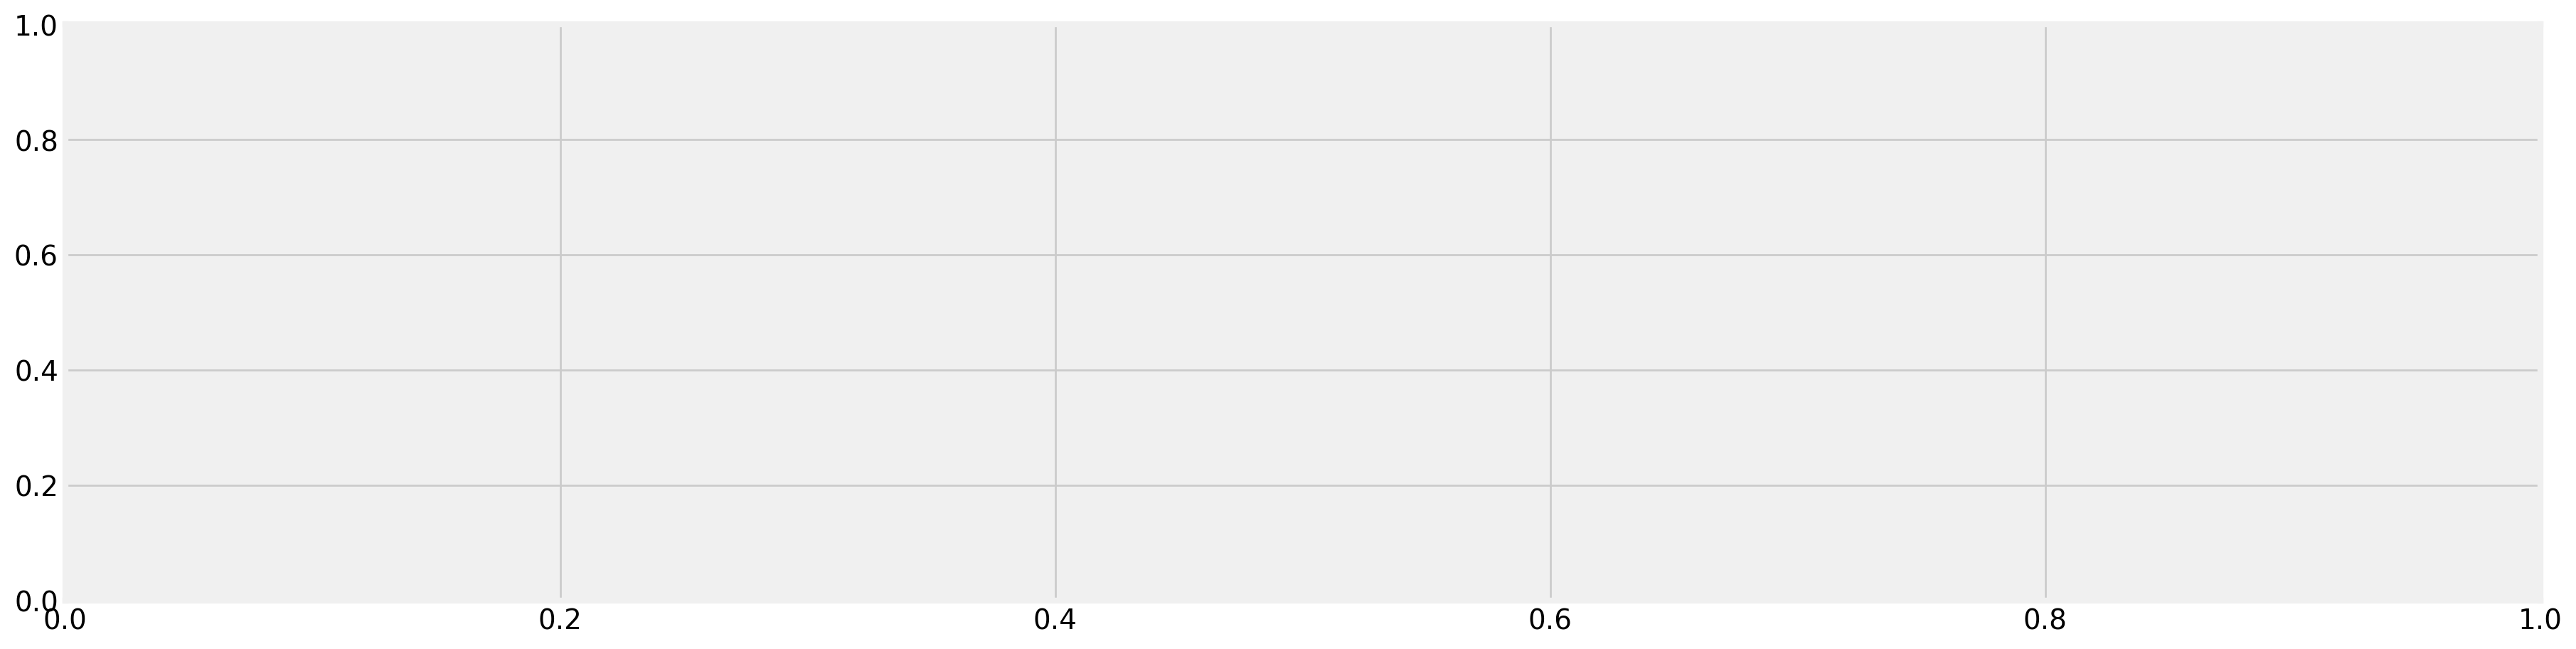

In [22]:
# Change to scatters
fig, ax = plt.subplots(1,1,figsize=(20,5), dpi= 200, facecolor='w', edgecolor='k')
selected_dp_df = dp_df[dp_df["predictor"] >= 5]
selected = selected_dp_df.groupby("date.x")["rank_filtered"].count()
plt.scatter(selected.index, selected, label="DPs Threshold=5")
plt.plot(capacity_df[capacity_df["datetime"].isin(selected.index)]["datetime"], capacity_df[capacity_df["datetime"].isin(selected.index)]["capacity"], label="CDPHE", color='r')
plt.legend()
plt.xlabel("Date")
plt.ylabel("Number of Investigations")
plt.title("Number of Investigations at each Decision Point CDPHE vs Threshold")

In [ ]:
# Change to scatters
fig, ax = plt.subplots(1,1,figsize=(20,5), dpi= 200, facecolor='w', edgecolor='k')
selected_dp_df = dp_df[dp_df["predictor"] >= 5]
selected = selected_dp_df.groupby("date.x")["rank_filtered"].count()
plt.scatter(all_selected.index, all_selected, label="All Datetime Threshold=5")
plt.scatter(selected.index, selected, label="DPs Threshold=5")
plt.plot(capacity_df[capacity_df["datetime"].isin(selected.index)]["datetime"], capacity_df[capacity_df["datetime"].isin(selected.index)]["capacity"], label="CDPHE", color='g')
plt.legend()
plt.xlabel("Date")
plt.ylabel("Number of Investigations")
plt.title("Number of Investigations at each Decision Point CDPHE vs Threshold")

In [ ]:
selected.index

In [ ]:
selected_value_counts = pd.DataFrame(selected.value_counts())
selected_value_counts = selected_value_counts.sort_index()
#selected_value_counts["cumsum_rank_filtered"] = selected_value_counts["rank_filtered"].cumsum(axis=0)
selected_value_counts

In [ ]:
capacity_df[capacity_df["datetime"].isin(selected.index)]["capacity"].value_counts().sort_index()

### Evaluate CDPHE and TLGRF

In [ ]:
#dp_df.to_csv("../data/CDPHE_TLGRF_historical.csv", index=False)

In [ ]:
changepoint_panel_df[(changepoint_panel_df["datetime"] == "2020-03-23") & (changepoint_panel_df["changepoint"] == 1)]

In [ ]:
overall_thresh[overall_thresh["date.x"] == "2020-03-23"]

In [ ]:
colorado_TLGRF[colorado_TLGRF["date.x"]=="2020-03-23"]